# **Проэкт: "Оптимизация инвестиционного портфеля по модели Марковица"**

# **ПОСТАНОВКА ЗАДАЧИ**

**Постановка задачи:**

Задача исследования состоит в том, чтобы на основе исторических рыночных данных по 12 активам сформировать и проанализировать инвестиционный портфель по модели Марковица, определить структуру портфеля с наилучшим соотношением доходности и риска, а также построить эффективную границу.
Для решения задачи используются реальные данные о ценах закрытия активов за период с **01.01.2016 по 01.01.2026**. Выбраны 12 активов:
**AAPL, MSFT, GOOGL, AMZN, NVDA, META, TSLA, JPM, XOM, KO, GLD, BTC-USD.**

На основе исторических цен необходимо :

*   рассчитать доходности по каждому активу;
*   определить среднюю ожидаемую доходность активов;

*   построить ковариационную матрицу доходностей;
*   рассчитать риск и ожидаемую доходность различных комбинаций активов;

найти:

*   портфель минимального риска;
*   портфель максимальной доходности;

*   портфель максимальной доходности при заданном уровне риска;

*   портфель с максимальным коэффициентом Шарпа;

построить эффективную границу Марковица и сравнить полученные портфели и сделать вывод о наиболее рациональной структуре инвестиций.


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **ИСХОДНЫЕ ДАННЫЕ**

На данном этапе были загружены исторические данные по ценам активов за выбранный период с использованием библиотеки **yfinance.**
Полученные данные представляют собой временной ряд цен активов, который используется для:

*   расчёта доходностей
*   оценки риска
*   построения портфелей







In [122]:
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

tickers = ["AAPL", "MSFT", "GOOGL",  "AMZN", "NVDA", "META", "TSLA","JPM","XOM", "KO","BTC-USD","GLD"]
data = yf.download(tickers, start="2016-01-01", end="2026-01-01",progress=False)
stock_prices = data["Close"].ffill().dropna().reset_index()

stock_prices

Ticker,Date,AAPL,AMZN,BTC-USD,GLD,GOOGL,JPM,KO,META,MSFT,NVDA,TSLA,XOM
0,2016-01-04,23.730947,31.849501,433.091003,102.889999,37.660732,48.401134,30.753250,101.424065,47.874187,0.789545,14.894000,49.654366
1,2016-01-05,23.136263,31.689501,431.959991,103.180000,37.764378,48.484825,30.862043,101.930115,48.092602,0.802229,14.895333,50.077454
2,2016-01-06,22.683495,31.632500,429.105011,104.669998,37.655277,47.784908,30.695219,102.168236,47.218983,0.769056,14.602667,49.660786
3,2016-01-07,21.726152,30.396999,458.048004,106.150002,36.746288,45.852505,30.187504,97.157562,45.576580,0.738567,14.376667,48.865910
4,2016-01-08,21.841034,30.352501,453.230011,105.680000,36.245930,44.825443,30.107719,96.572151,45.716354,0.722713,14.066667,47.878712
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3645,2025-12-27,273.144409,232.520004,87802.156250,416.739990,313.289459,324.775421,69.392860,662.722595,486.599365,190.519684,475.190002,118.321342
3646,2025-12-28,273.144409,232.520004,87835.835938,416.739990,313.289459,324.775421,69.392860,662.722595,486.599365,190.519684,475.190002,118.321342
3647,2025-12-29,273.504089,232.070007,87138.140625,398.600006,313.339417,320.655182,69.680878,658.126526,485.990753,188.209808,459.640015,119.731941
3648,2025-12-30,272.824707,232.529999,88430.132812,398.890015,313.629242,320.328369,69.591492,665.380310,486.369904,187.529846,454.429993,120.188896


Для дальнейших расчётов (доходности, риска, ковариации) используются **только числовые данные**.
Столбец с датами не участвует в математических операциях
его удаление упрощает обработку данных.

In [38]:
stock_prices_drop_date = stock_prices.drop(columns=['Date'])
stock_prices_drop_date

Ticker,AAPL,AMZN,BTC-USD,GLD,GOOGL,JPM,KO,META,MSFT,NVDA,TSLA,XOM
0,23.730947,31.849501,433.091003,102.889999,37.660732,48.401134,30.753250,101.424065,47.874187,0.789545,14.894000,49.654366
1,23.136263,31.689501,431.959991,103.180000,37.764378,48.484825,30.862043,101.930115,48.092602,0.802229,14.895333,50.077454
2,22.683495,31.632500,429.105011,104.669998,37.655277,47.784908,30.695219,102.168236,47.218983,0.769056,14.602667,49.660786
3,21.726152,30.396999,458.048004,106.150002,36.746288,45.852505,30.187504,97.157562,45.576580,0.738567,14.376667,48.865910
4,21.841034,30.352501,453.230011,105.680000,36.245930,44.825443,30.107719,96.572151,45.716354,0.722713,14.066667,47.878712
...,...,...,...,...,...,...,...,...,...,...,...,...
3645,273.144409,232.520004,87802.156250,416.739990,313.289459,324.775421,69.392860,662.722595,486.599365,190.519684,475.190002,118.321342
3646,273.144409,232.520004,87835.835938,416.739990,313.289459,324.775421,69.392860,662.722595,486.599365,190.519684,475.190002,118.321342
3647,273.504089,232.070007,87138.140625,398.600006,313.339417,320.655182,69.680878,658.126526,485.990753,188.209808,459.640015,119.731941
3648,272.824707,232.529999,88430.132812,398.890015,313.629242,320.328369,69.591492,665.380310,486.369904,187.529846,454.429993,120.188896


# **ПОСТРОЕНИЕ ГРАФИКА ЦЕН АКТИВА**

На данном этапе был построен график изменения цены выбранного актива за длительный период времени.
График позволяет:

*   увидеть общий тренд актива
*   определить периоды роста и падения

*   оценить диапазон колебаний цены







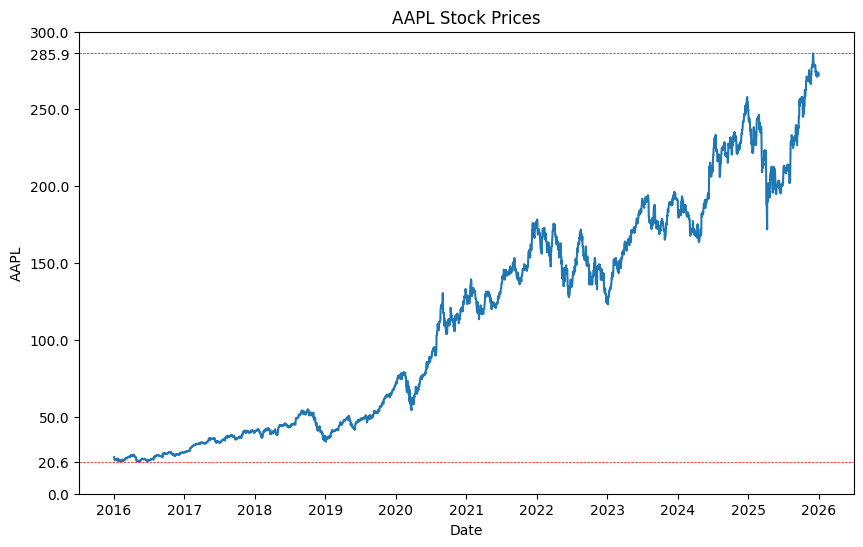

In [39]:
asset = 'AAPL'

plt.figure(figsize=(10,6))
sns.lineplot(x='Date',y= asset,data=stock_prices)

min_val = stock_prices[asset].min()
max_val = stock_prices[asset].max()

plt.axhline(min_val,color='red',linestyle='--',linewidth='0.5')
plt.axhline(max_val,color='green',linestyle='--',linewidth='0.5')
plt.title(f"{asset} Stock Prices")
yticks = list(plt.yticks()[0])
yticks.extend([min_val,max_val])
plt.yticks(sorted(yticks))


plt.show()

# **РАСЧЕТ ДОХОДНОСТИ АКТИВОВ**

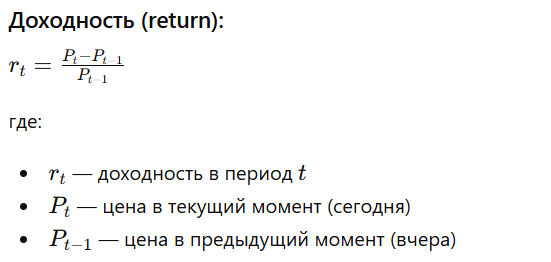

На данном этапе были рассчитаны дневные доходности активов на основе исторических цен.

Доходности являются основой для дальнейших расчётов:

*   ожидаемой доходности портфеля
*   риска (волатильности)

*   ковариационной матрицы





In [40]:
returns = stock_prices_drop_date.pct_change().dropna()
returns



Ticker,AAPL,AMZN,BTC-USD,GLD,GOOGL,JPM,KO,META,MSFT,NVDA,TSLA,XOM
1,-0.025059,-0.005024,-0.002611,0.002819,0.002752,0.001729,0.003538,0.004989,0.004562,0.016064,0.000090,0.008521
2,-0.019570,-0.001799,-0.006609,0.014441,-0.002889,-0.014436,-0.005405,0.002336,-0.018165,-0.041350,-0.019648,-0.008320
3,-0.042204,-0.039058,0.067450,0.014140,-0.024140,-0.040440,-0.016541,-0.049043,-0.034783,-0.039645,-0.015477,-0.016006
4,0.005288,-0.001464,-0.010519,-0.004428,-0.013617,-0.022399,-0.002643,-0.006025,0.003067,-0.021467,-0.021563,-0.020202
5,0.000000,0.000000,-0.012398,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
3645,0.000000,0.000000,0.005736,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3646,0.000000,0.000000,0.000384,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3647,0.001317,-0.001935,-0.007943,-0.043528,0.000159,-0.012686,0.004151,-0.006935,-0.001251,-0.012124,-0.032724,0.011922
3648,-0.002484,0.001982,0.014827,0.000728,0.000925,-0.001019,-0.001283,0.011022,0.000780,-0.003613,-0.011335,0.003816


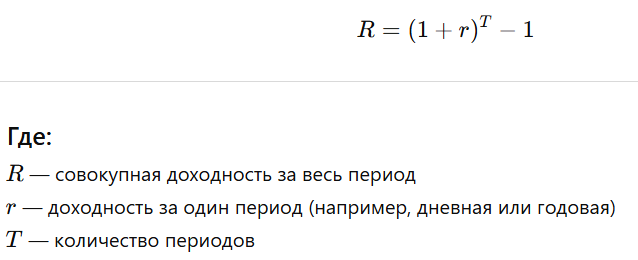

На данном этапе была рассчитана общая доходность каждого актива за весь период с использованием сложного процента.

In [41]:
total_return = ((1 + returns).prod() - 1).reset_index().rename(columns={0:'Total_Return'})
total_return


,Ticker,Total_Return
0,AAPL,10.445217
1,AMZN,6.247210
2,BTC-USD,201.056444
3,GLD,2.851783
4,GOOGL,7.305197
5,JPM,5.593643
6,KO,1.257732
7,META,5.502651
8,MSFT,9.078890
9,NVDA,235.199185


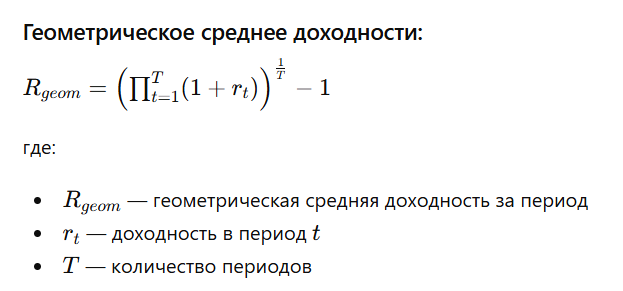

На данном этапе была рассчитана средняя доходность активов с учётом сложного процента.

Геометрическое среднее учитывает эффект сложного процента и показывает реальную среднюю доходность инвестиций.

Геометрическая доходность даёт более точную оценку реальной доходности инвестиций по сравнению с простым средним.

In [42]:
expected_return = (((1 + returns).prod(axis=0))**(1/len(returns))-1).reset_index().rename(columns={0:'Daily_Expected_Return'})
expected_return['Weekly_Expected_Return'] = (1 + expected_return['Daily_Expected_Return'])**7 - 1
expected_return['Monthly_Expected_Return'] = (1 + expected_return['Daily_Expected_Return'])**30 - 1
expected_return['Annual_Expected_Return'] = (1 + expected_return['Daily_Expected_Return'])**365 - 1
expected_return

,Ticker,Daily_Expected_Return,Weekly_Expected_Return,Monthly_Expected_Return,Annual_Expected_Return
0,AAPL,0.000668,0.004687,0.020242,0.276120
1,AMZN,0.000543,0.003807,0.016417,0.219104
2,BTC-USD,0.001456,0.010236,0.044610,0.700632
3,GLD,0.000370,0.002590,0.011149,0.144412
4,GOOGL,0.000580,0.004069,0.017556,0.235834
5,JPM,0.000517,0.003625,0.015627,0.207633
6,KO,0.000223,0.001563,0.006718,0.084868
7,META,0.000513,0.003598,0.015511,0.205956
8,MSFT,0.000633,0.004442,0.019177,0.259995
9,NVDA,0.001499,0.010538,0.045952,0.727400


На этапе проверки , перевели средние дневные доходности в годовые и годовые в суммарные за 10 лет. Результаты совпали

In [43]:
proverka_daily_to_annual = (1 + expected_return['Daily_Expected_Return'])**365 - 1
proverka_daily_to_annual = proverka_daily_to_annual.reset_index().rename(columns={'Daily_Expected_Return':'Annual_Return'}).drop(columns='index')

proverka_annual_to_10_years = (1 + expected_return['Annual_Expected_Return'])**10 - 1
proverka_annual_to_10_years = proverka_annual_to_10_years.reset_index().rename(columns={'Annual_Expected_Return':'Total_Return'}).drop(columns='index')

result_proverka = pd.concat([proverka_daily_to_annual, proverka_annual_to_10_years],axis=1)
result_proverka

,Annual_Return,Total_Return
0,0.276120,10.452865
1,0.219104,6.251144
2,0.700632,201.350609
3,0.144412,2.853207
4,0.235834,7.310017
5,0.207633,5.597052
6,0.084868,1.258236
7,0.205956,5.505989
8,0.259995,9.085274
9,0.727400,235.553178


# **РАСЧЕТ РИСКА АКТИВОВ**

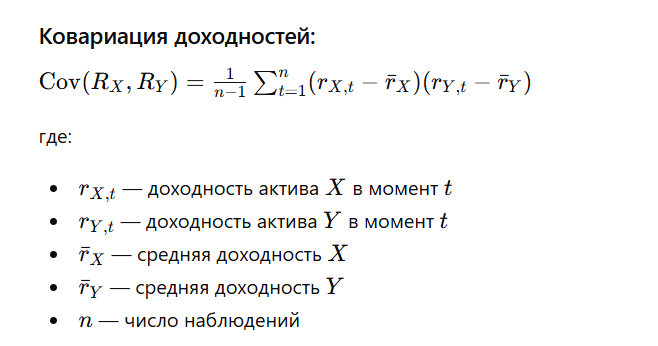

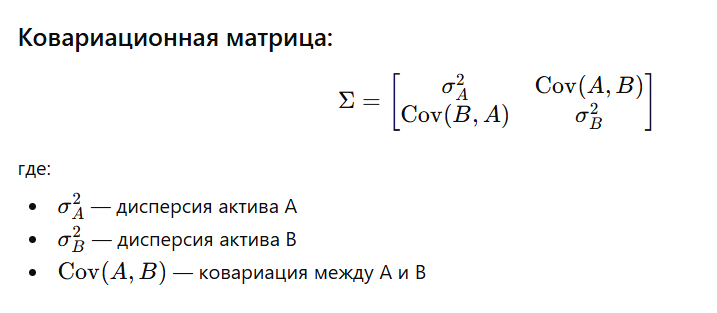

Ковариация показывает направление движения активов: > 0 → активы движутся вместе

< 0 → движутся в разные стороны

≈ 0 → не связаны

Матрица показывает:

*   риск каждого актива (по диагонали)
*   взаимосвязь между активами (вне диагонали)



In [44]:
cov_mat = returns.cov()
cov_mat

Ticker,AAPL,AMZN,BTC-USD,GLD,GOOGL,JPM,KO,META,MSFT,NVDA,TSLA,XOM
Ticker,,,,,,,,,,,,
AAPL,0.000231,0.000150,0.000092,0.000004,0.000140,0.000091,0.000048,0.000160,0.000144,0.000213,0.000208,0.000067
AMZN,0.000150,0.000294,0.000103,0.000005,0.000165,0.000076,0.000028,0.000210,0.000160,0.000242,0.000218,0.000045
BTC-USD,0.000092,0.000103,0.001236,0.000026,0.000097,0.000071,0.000020,0.000107,0.000098,0.000174,0.000185,0.000056
GLD,0.000004,0.000005,0.000026,0.000060,0.000006,-0.000010,0.000005,0.000004,0.000003,0.000005,0.000009,0.000005
GOOGL,0.000140,0.000165,0.000097,0.000006,0.000227,0.000088,0.000041,0.000186,0.000149,0.000213,0.000183,0.000058
JPM,0.000091,0.000076,0.000071,-0.000010,0.000088,0.000208,0.000056,0.000092,0.000088,0.000126,0.000124,0.000112
KO,0.000048,0.000028,0.000020,0.000005,0.000041,0.000056,0.000089,0.000033,0.000047,0.000036,0.000037,0.000050
META,0.000160,0.000210,0.000107,0.000004,0.000186,0.000092,0.000033,0.000406,0.000169,0.000259,0.000210,0.000053
MSFT,0.000144,0.000160,0.000098,0.000003,0.000149,0.000088,0.000047,0.000169,0.000196,0.000226,0.000180,0.000054


Делаем расчет анализа риска активов. Рассчитали дисперсию (расброс доходностей)  и стандартное отклонение (волатильность дневной доходности).

In [45]:
val_vol_returns = pd.DataFrame({'Daily_Variance_Returns':returns.var(),'Daily_Volatility_Returns':returns.std()})
val_vol_returns = val_vol_returns.reset_index()
val_vol_returns




,Ticker,Daily_Variance_Returns,Daily_Volatility_Returns
0,AAPL,0.000231,0.015195
1,AMZN,0.000294,0.017152
2,BTC-USD,0.001236,0.035158
3,GLD,0.000060,0.007742
4,GOOGL,0.000227,0.015079
5,JPM,0.000208,0.014423
6,KO,0.000089,0.009443
7,META,0.000406,0.020139
8,MSFT,0.000196,0.013995
9,NVDA,0.000682,0.026111


# **РАСЧЕТ РИСКА, ДОХОДНОСТИ и КОЭФФИЦИЕНТА ШАРПА ДЛЯ РАВНОВЗВЕШЕННОГО ПОРТФЕЛЯ**

На данном этапе были рассчитаны веса активов для равновзвешенного портфеля.
Каждому активу присваивается одинаковый вес:

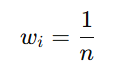

Таким образом, был получен базовый набор весов, при котором капитал равномерно распределён между всеми активами.

In [46]:
n = len(total_return['Total_Return'])
weights = np.ones(n) / n
print(weights)

[0.08333333 0.08333333 0.08333333 0.08333333 0.08333333 0.08333333
 0.08333333 0.08333333 0.08333333 0.08333333 0.08333333 0.08333333]


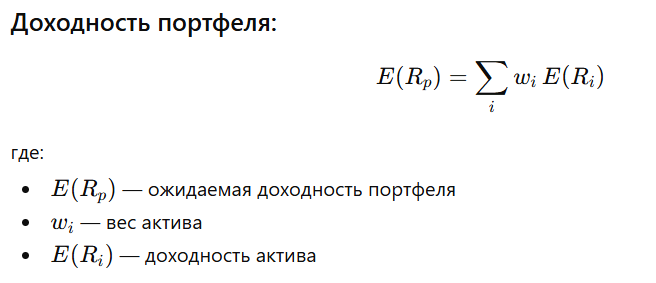

**Доходность портфеля** определяется как взвешенная сумма доходностей всех входящих в него активов.
Доходность портфеля определяется не только отдельными активами, но и их весами.
Для анализа портфеля доходность, рассчитанная на дневной основе, переводится в **годовую** с учётом **сложного процента**.


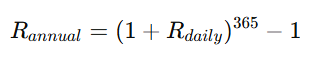

In [47]:
portfolio_return = np.dot(weights, expected_return['Daily_Expected_Return'])
print(f"Daily Equal Weight Portfolio Return = {portfolio_return}")

annual_portfolio_return =(1+portfolio_return)**365 - 1
print(f"Annual Equal Weight Portfolio Return = {annual_portfolio_return}")

Daily Equal Weight Portfolio Return = 0.0006814622059024649
Annual Equal Weight Portfolio Return = 0.28229185978703497


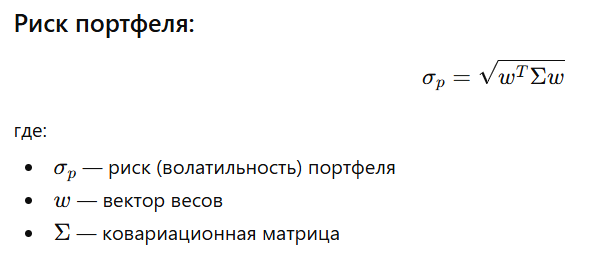

**Риск (волатильность) портфеля** рассчитывается с использованием **ковариационной матрицы активов и их весов**.
Риск портфеля зависит не только от отдельных активов, но и от их взаимной корреляции.
**Диверсификация** позволяет снижать риск портфеля за счёт комбинации активов с различной динамикой доходности.
Для корректного анализа портфеля риск, рассчитанный на дневной основе, переводится в **годовой показатель**.

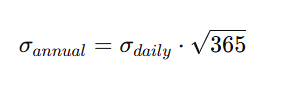

In [48]:
portfolio_risk = np.sqrt(np.dot(weights.T,np.dot(cov_mat,weights)))
print(f"Daily Equal Weight Portfolio Risk = {portfolio_risk}")
annual_portfolio_risk = portfolio_risk*np.sqrt(365)
print(f"Annual Equal Weight Portfolio Risk = {annual_portfolio_risk}")

Daily Equal Weight Portfolio Risk = 0.011298110919494382
Annual Equal Weight Portfolio Risk = 0.21585010603994925


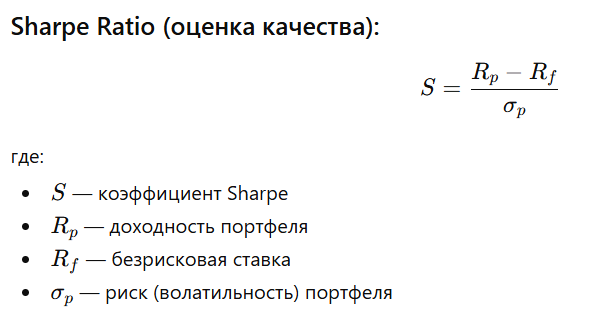

Коэффициент **Sharpe Ratio** используется для оценки эффективности инвестиционного портфеля с учётом риска. Он показывает, сколько дополнительной доходности инвестор получает за каждую единицу риска.
Разница показывает(Rp - Rf), насколько портфель обгоняет безрисковый актив.

Sharpe Ratio < 1    - слабый портфель,
Sharpe Ratio 1 - 2  - хороший портфель,
Sharpe Ratio > 2     - отличный портфель.


**Безрисковая ставка (Risk-Free-Rate)** — это доходность актива, который считается практически свободным от риска. Она используется как базовый ориентир для сравнения эффективности инвестиционного портфеля. На практике абсолютно безрисковых активов не существует, но используются максимально надёжные инструменты. В качестве безрисковой ставки берут **гособлигации (T - Bills)** с доходностью 2% - 3% годовых.

In [49]:
rf = 0.02
sharpe_ratio = (annual_portfolio_return - rf)/annual_portfolio_risk
print(f"Sharpe Ratio Equal Weight Portfolio = {sharpe_ratio}")

Sharpe Ratio Equal Weight Portfolio = 1.2151574284540325


 **РАВНОВЗВЕШЕННЫЙ ПОРТФЕЛЬ**

В данном этапе был построен равновзвешенный портфель, в котором каждому активу присваивается одинаковый вес.
**Равновзвешенный портфель** служит отправной точкой анализа,но **не является оптимальным** и для достижения оптимальных результатов необходимо варьировать веса активов и искать наиболее эффективные комбинации.
Изменяя веса активов, инвестор может управлять ожидаемой доходностью портфеля и адаптировать его под свои цели.

In [50]:
print(f"Annual Equal Weight Portfolio Return = {annual_portfolio_return}")
print(f"Annual Equal Weight Portfolio Risk = {annual_portfolio_risk}")
print(f"Sharpe Ratio Equal Weight Portfolio = {sharpe_ratio}")

weights_ticker_equal_weight = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': weights,
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_equal_weight



Annual Equal Weight Portfolio Return = 0.28229185978703497
Annual Equal Weight Portfolio Risk = 0.21585010603994925
Sharpe Ratio Equal Weight Portfolio = 1.2151574284540325


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.083333,0.000668,0.015195,0.276120
1,AMZN,0.083333,0.000543,0.017152,0.219104
2,BTC-USD,0.083333,0.001456,0.035158,0.700632
3,GLD,0.083333,0.000370,0.007742,0.144412
4,GOOGL,0.083333,0.000580,0.015079,0.235834
5,JPM,0.083333,0.000517,0.014423,0.207633
6,KO,0.083333,0.000223,0.009443,0.084868
7,META,0.083333,0.000513,0.020139,0.205956
8,MSFT,0.083333,0.000633,0.013995,0.259995
9,NVDA,0.083333,0.001499,0.026111,0.727400


# **ГЕНЕРАЦИЯ СЛУЧАЙНЫХ ПОРТФЕЛЕЙ**

В данном блоке кода выполняется генерация случайных портфелей с учётом заданных ограничений (min_w , max_w) на веса активов. Это обеспечивает диверсификацию и исключает чрезмерную концентрацию капитала.
Рассчитывают **дневные риск и доходность портфелей** , затем переводится в годовую. Также сохраняется **годовой Sharpe Ratio и веса портфелей**


In [51]:
num_portfolios = 1000000

results = []

min_w = 0.02
max_w = 0.25
while len(results) < num_portfolios:
  weight = np.random.random(n)
  weight /= np.sum(weight)
  if np.any(weight < min_w) or np.any(weight > max_w):
    continue

  ret = np.dot(weight, expected_return['Daily_Expected_Return'])
  annual_ret = (1 + ret)**365 - 1
  risk = np.sqrt(np.dot(weight.T, np.dot(cov_mat, weight)))
  annual_risk = risk * np.sqrt(365)
  sharpe = (annual_ret - rf)/annual_risk
  results.append((annual_ret, annual_risk, sharpe, weight))








In [52]:
df_results = pd.DataFrame(results, columns=['Return', 'Risk', 'Sharpe', 'Weights'])
df_results["Return"] = df_results["Return"].round(4)
df_results["Risk"] = df_results["Risk"].round(4)
df_results["Sharpe"] = df_results["Sharpe"].round(4)
df_results["Weights"] = df_results["Weights"].round(2)

df_results['Risk'].count()
df_results

,Return,Risk,Sharpe,Weights
0,0.3050,0.2318,1.2294,"[0.10710271598154028, 0.02226903484498493, 0.1..."
1,0.2561,0.2111,1.1183,"[0.1437866655977914, 0.13744404276002925, 0.05..."
2,0.3112,0.2303,1.2644,"[0.04443178132909171, 0.0636666772566593, 0.09..."
3,0.2861,0.2110,1.2615,"[0.15460269988236966, 0.07432207286667039, 0.0..."
4,0.3198,0.2369,1.2654,"[0.03502203064190057, 0.11333890115590632, 0.0..."
...,...,...,...,...
999995,0.3273,0.2301,1.3357,"[0.04537866092671253, 0.03900255162409253, 0.1..."
999996,0.2842,0.2323,1.1373,"[0.11438393312035802, 0.10515550168118996, 0.0..."
999997,0.2490,0.2061,1.1110,"[0.0903315900313638, 0.10384682763867051, 0.02..."
999998,0.2644,0.2138,1.1427,"[0.07117796370503053, 0.08164177333350334, 0.0..."


После генерации случайных портфелей была проведена описательная статистика **(max - min)** ключевых показателей: **доходности (Return), риска (Risk) и коэффициента Sharpe.**

In [53]:
df_results.describe()

,Return,Risk,Sharpe
count,1000000.000000,1000000.000000,1000000.000000
mean,0.282503,0.219693,1.193958
std,0.025910,0.014902,0.071843
min,0.184600,0.154600,0.895700
25%,0.264600,0.209600,1.146300
50%,0.282100,0.219400,1.196700
75%,0.299700,0.229400,1.244300
max,0.449400,0.308600,1.470900


# **ПОСТРОЕНИЕ ЭФФЕКТИВНОЙ ГРАНИЦЫ EFFICIENT FRONTIER**

В данном блоке кода осуществляется **построение эффективной границы** на основе ранее сгенерированных портфелей.
**Эффективная граница** представляет собой множество портфелей, которые обеспечивают **максимальную доходность при заданном уровне риска.**
Алгоритм работает следующим образом:

Проходим по портфелям в порядке роста риска.
Для каждого портфеля проверяем является ли его доходность выше всех предыдущих.
Если да то добавляем его в эффективную границу.

Таким образом остаются только портфели, дают максимальную доходность при данном уровне риска

In [115]:
df_results_sort_risk  =  df_results.sort_values('Risk')
frontier = []
max_return = -np.inf

for _, row in df_results_sort_risk.iterrows():
    if row['Return'] > max_return:
        frontier.append(row)
        max_return = row['Return']

frontier = pd.DataFrame(frontier)
frontier


,Return,Risk,Sharpe,Weights
800775,0.1891,0.1546,1.0943,"[0.03655471340350427, 0.041838892860183934, 0...."
470379,0.2021,0.1548,1.1763,"[0.04787023834788047, 0.02312328014465527, 0.0..."
952833,0.2035,0.1567,1.1707,"[0.03202970727213526, 0.07458072313914943, 0.0..."
435085,0.2125,0.1585,1.2145,"[0.05144485753126286, 0.03181928082719157, 0.0..."
742191,0.2197,0.1590,1.2563,"[0.06505900444847508, 0.03687180284423476, 0.0..."
...,...,...,...,...
606522,0.4076,0.2693,1.4393,"[0.0717842952005144, 0.035961020718912655, 0.2..."
402124,0.4128,0.2743,1.4323,"[0.12398833716153074, 0.03405397298807444, 0.2..."
856846,0.4200,0.2814,1.4215,"[0.026717566703605658, 0.09202361070423662, 0...."
308472,0.4236,0.2825,1.4286,"[0.07280807472033293, 0.04971837749731327, 0.2..."


# **ПОРТФЕЛЬ МИНИМАЛЬНОГО РИСКА**

В данном блоке кода осуществляется поиск портфеля с минимальным уровнем риска среди всех сгенерированных комбинаций. Таким образом выбирается наиболее **консервативный портфель**.                                               
Данный портфель характеризуется:

*   минимальной волатильностью,
*   относительно стабильной доходностью

*   умеренным значением Sharpe








In [116]:
min_risk_portfolio = df_results.loc[df_results['Risk'].idxmin()]
print(min_risk_portfolio.drop('Weights').to_string())

weights_ticker_min_risk = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': min_risk_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_min_risk



Return    0.1891
Risk      0.1546
Sharpe    1.0943


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.036555,0.000668,0.015195,0.276120
1,AMZN,0.041839,0.000543,0.017152,0.219104
2,BTC-USD,0.027190,0.001456,0.035158,0.700632
3,GLD,0.249102,0.000370,0.007742,0.144412
4,GOOGL,0.070316,0.000580,0.015079,0.235834
5,JPM,0.073231,0.000517,0.014423,0.207633
6,KO,0.229066,0.000223,0.009443,0.084868
7,META,0.146497,0.000513,0.020139,0.205956
8,MSFT,0.049911,0.000633,0.013995,0.259995
9,NVDA,0.020524,0.001499,0.026111,0.727400


# **ПОРТФЕЛЬ МАКСИМАЛЬНОГО РИСКА**

В данном блоке кода осуществляется поиск портфеля с максимальным уровнем риска среди всех сгенерированных комбинаций.
Таким образом выбирается наиболее **агрессивный портфель**

Данный портфель характеризуется:


*   максимальной волатильностью,
*   высокой ожидаемой доходностью,

*   потенциально высоким, но менее стабильным Sharpe.













In [56]:
max_risk_portfolio = df_results.loc[df_results['Risk'].idxmax()]
print(max_risk_portfolio.drop('Weights').to_string())

weights_ticker_max_risk = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': max_risk_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_max_risk


Return    0.4429
Risk      0.3086
Sharpe    1.3701


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.048729,0.000668,0.015195,0.276120
1,AMZN,0.034423,0.000543,0.017152,0.219104
2,BTC-USD,0.228552,0.001456,0.035158,0.700632
3,GLD,0.042086,0.000370,0.007742,0.144412
4,GOOGL,0.050092,0.000580,0.015079,0.235834
5,JPM,0.068571,0.000517,0.014423,0.207633
6,KO,0.020285,0.000223,0.009443,0.084868
7,META,0.073468,0.000513,0.020139,0.205956
8,MSFT,0.020653,0.000633,0.013995,0.259995
9,NVDA,0.205788,0.001499,0.026111,0.727400


# **ПОРТФЕЛЬ С МАКСИМАЛЬНЫМ КОЭФФИЦИЕНТОМ ШАРПА**

В данном блоке кода определяется портфель с максимальным значением коэффициента Sharpe, который считается **оптимальным с точки зрения соотношения риск/доходность**.
                                         Данный портфель:

*   не является ни самым рискованным, ни самым доходным
*   но даёт лучший баланс между ними





In [57]:
max_sharpe_portfolio = df_results.loc[df_results['Sharpe'].idxmax()]
print(max_sharpe_portfolio.drop('Weights').to_string())

weights_ticker_max_sharpe = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': max_sharpe_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_max_sharpe



Return    0.3635
Risk      0.2335
Sharpe    1.4709


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.088280,0.000668,0.015195,0.276120
1,AMZN,0.032530,0.000543,0.017152,0.219104
2,BTC-USD,0.152291,0.001456,0.035158,0.700632
3,GLD,0.144031,0.000370,0.007742,0.144412
4,GOOGL,0.085103,0.000580,0.015079,0.235834
5,JPM,0.081325,0.000517,0.014423,0.207633
6,KO,0.089007,0.000223,0.009443,0.084868
7,META,0.029366,0.000513,0.020139,0.205956
8,MSFT,0.040854,0.000633,0.013995,0.259995
9,NVDA,0.214166,0.001499,0.026111,0.727400


# **ПОРТФЕЛЬ С МИНИМАЛЬНЫМ КОЭФФИЦИЕНТОМ ШАРПА**

В данном блоке кода определяется портфель с минимальным значением коэффициента Sharpe среди всех сгенерированных комбинаций. Данный портфель является **наименее эффективным с точки зрения соотношения риск/доходность**

Данный портфель:

*   имеет низкую эффективность
*   не компенсирует риск достаточной доходностью





In [58]:
min_sharpe_portfolio = df_results.loc[df_results['Sharpe'].idxmin()]
print(min_sharpe_portfolio.drop('Weights').to_string())


weights_ticker_min_sharpe = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': min_sharpe_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_min_sharpe

Return    0.2175
Risk      0.2205
Sharpe    0.8957


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.020617,0.000668,0.015195,0.276120
1,AMZN,0.196423,0.000543,0.017152,0.219104
2,BTC-USD,0.033637,0.001456,0.035158,0.700632
3,GLD,0.059310,0.000370,0.007742,0.144412
4,GOOGL,0.135506,0.000580,0.015079,0.235834
5,JPM,0.024083,0.000517,0.014423,0.207633
6,KO,0.067617,0.000223,0.009443,0.084868
7,META,0.222550,0.000513,0.020139,0.205956
8,MSFT,0.038116,0.000633,0.013995,0.259995
9,NVDA,0.029817,0.001499,0.026111,0.727400


# **ПОРТФЕЛЬ С МАКСИМАЛЬНОЙ ДОХОДНОСТЬЮ ПРИ ЗАДАННОМ РИСКЕ**

В данном блоке кода осуществляется поиск портфеля, который обеспечивает максимальную доходность при ограничении на уровень риска.
Это **оптимальный портфель при заданном ограничении риска** лежит на эффективной границе

In [59]:
target_risk = 0.2

filtered_portfolios = df_results[df_results['Risk']<= target_risk]
max_return_given_risk = filtered_portfolios.loc[filtered_portfolios['Return'].idxmax()]
print(max_return_given_risk.drop('Weights').to_string())


weights_ticker_max_return_given_risk = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': max_return_given_risk['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_max_return_given_risk

Return    0.3063
Risk      0.1991
Sharpe     1.438


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.049127,0.000668,0.015195,0.276120
1,AMZN,0.055790,0.000543,0.017152,0.219104
2,BTC-USD,0.115634,0.001456,0.035158,0.700632
3,GLD,0.187509,0.000370,0.007742,0.144412
4,GOOGL,0.064613,0.000580,0.015079,0.235834
5,JPM,0.100498,0.000517,0.014423,0.207633
6,KO,0.144597,0.000223,0.009443,0.084868
7,META,0.028510,0.000513,0.020139,0.205956
8,MSFT,0.025631,0.000633,0.013995,0.259995
9,NVDA,0.164645,0.001499,0.026111,0.727400


# **ПОРТФЕЛЬ С МАКСИМАЛЬНОЙ ДОХОДНОСТЬЮ**

В данном блоке кода определяется портфель с максимальной ожидаемой доходностью среди всех сгенерированных комбинаций. Данный портфель обеспечивает **максимальный уровень ожидаемой прибыли**
данный портфель:

*   имеет наивысшую доходность среди всех вариантов
*   сопровождается высоким уровнем риска





In [60]:
max_profit_portfolio = df_results.loc[df_results['Return'].idxmax()]
print(max_profit_portfolio.drop('Weights').to_string())


weights_ticker_max_profit = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': max_profit_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_max_profit





Return    0.4494
Risk      0.3014
Sharpe    1.4249


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.059068,0.000668,0.015195,0.276120
1,AMZN,0.025956,0.000543,0.017152,0.219104
2,BTC-USD,0.245057,0.001456,0.035158,0.700632
3,GLD,0.040007,0.000370,0.007742,0.144412
4,GOOGL,0.056868,0.000580,0.015079,0.235834
5,JPM,0.027242,0.000517,0.014423,0.207633
6,KO,0.053424,0.000223,0.009443,0.084868
7,META,0.061089,0.000513,0.020139,0.205956
8,MSFT,0.031002,0.000633,0.013995,0.259995
9,NVDA,0.248899,0.001499,0.026111,0.727400


# **ПОРТФЕЛЬ С МИНИМАЛЬНОЙ ДОХОДНОСТЬЮ**

В данном блоке кода определяется портфель с минимальной ожидаемой доходностью среди всех сгенерированных комбинаций. Данный портфель представляет **наименее прибыльный вариант**
Данный портфель:

*   имеет самую низкую доходность
*   при этом риск может оставаться на среднем уровне






In [61]:
min_profit_portfolio = df_results.loc[df_results['Return'].idxmin()]
print(min_profit_portfolio.drop('Weights').to_string())


weights_ticker_min_profit = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': min_profit_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_min_profit

Return    0.1846
Risk       0.167
Sharpe    0.9858


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.040559,0.000668,0.015195,0.276120
1,AMZN,0.052496,0.000543,0.017152,0.219104
2,BTC-USD,0.021848,0.001456,0.035158,0.700632
3,GLD,0.117840,0.000370,0.007742,0.144412
4,GOOGL,0.071674,0.000580,0.015079,0.235834
5,JPM,0.159691,0.000517,0.014423,0.207633
6,KO,0.222017,0.000223,0.009443,0.084868
7,META,0.030237,0.000513,0.020139,0.205956
8,MSFT,0.028865,0.000633,0.013995,0.259995
9,NVDA,0.022095,0.001499,0.026111,0.727400


# **CAPITAL MARKET LINE (CML)**

**Capital Market Line (CML)** — это линия, которая показывает оптимальное соотношение риска и доходности для портфелей, включающих безрисковый актив и рыночный портфель (портфель с максимальным Sharpe).

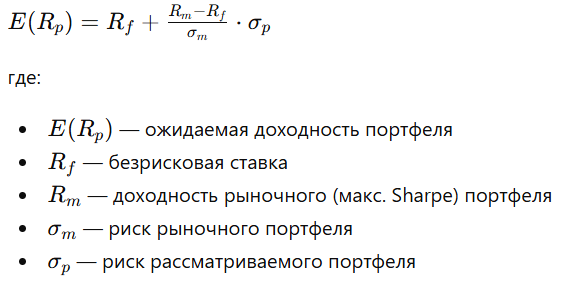

Линия **CML** показывает все возможные оптимальные портфели которые можно получить, комбинируя:

*   безрисковый актив (например, облигации)
*   рыночный портфель (max Sharpe)





In [62]:
risk_range = np.linspace(0, 0.5, 100)

cml = rf + (max_sharpe_portfolio['Return'] - rf) / max_sharpe_portfolio['Risk'] * risk_range

# **ПОСТРОЕНИЕ ГРАФИКА EFFICIENT FRONTIER - PORTFOLIO ALLOCATION**

На представленном графике отображается зависимость между риском и доходностью различных портфелей, а также ключевые ориентиры для принятия инвестиционных решений.
**Каждая точка** — это отдельный случайно сгенерированный портфель. **Цвет точек** отражает **коэффициент Sharpe**. Чем выше и левее точка — тем **эффективнее портфель**. **Efficient Frontier (красная линия)** показывает лучшие портфели при каждом уровне риска. Формируется как верхняя граница облака. Выше неё попасть невозможно.
Интерпретация:

*   большинство случайных портфелей лежат ниже Efficient Frontier - эти портфели не оптимальные
*   только небольшая часть — оптимальные, которые лежат на Efficient Frontier

*   портфель с max Sharpe задаёт наилучшую стратегию

Инвестор должен стремиться к портфелям, расположенным на **Efficient Frontier** и, в идеале, использовать комбинации вдоль **Capital Market Line** для достижения максимальной доходности на единицу риска.






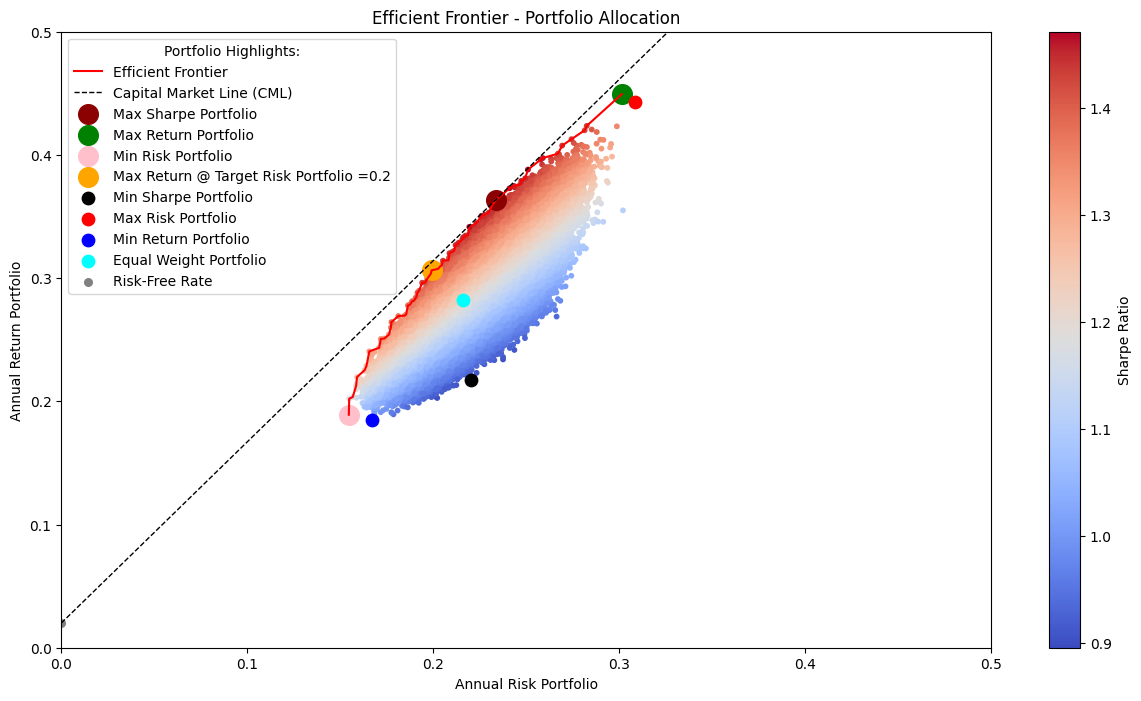

In [63]:
plt.figure(figsize=(15, 8))

sc = plt.scatter(df_results['Risk'], df_results['Return'],c = df_results['Sharpe'],cmap = 'coolwarm' ,s=10)
plt.colorbar(sc, label='Sharpe Ratio')


plt.plot(
    frontier['Risk'],
    frontier['Return'],
    color='red',
    linewidth=1.5,
    label='Efficient Frontier'
)

plt.plot(risk_range, cml, color='black', linestyle='--', linewidth=1, label='Capital Market Line (CML)')


plt.scatter(
    max_sharpe_portfolio['Risk'], max_sharpe_portfolio['Return'],
    marker='o', s=200, label='Max Sharpe Portfolio',color='darkred'
)

plt.scatter(
    max_profit_portfolio['Risk'],
    max_profit_portfolio['Return'],
    marker='o',
    s=200,
    label='Max Return Portfolio',
    color='green'
)

plt.scatter(
    min_risk_portfolio['Risk'], min_risk_portfolio['Return'],
    marker='o', s=200, label='Min Risk Portfolio', color='pink'
)

plt.scatter(
    max_return_given_risk['Risk'], max_return_given_risk['Return'],
    marker='o', s=200, label=f"Max Return @ Target Risk Portfolio ={target_risk}",color='orange'
)

plt.scatter(
    min_sharpe_portfolio['Risk'], min_sharpe_portfolio['Return'],
    marker='o', s=80, label='Min Sharpe Portfolio',color='black'
)

plt.scatter(
    max_risk_portfolio['Risk'],
    max_risk_portfolio['Return'],
    marker='o',
    s=80,
    label='Max Risk Portfolio',
    color='red'
)

plt.scatter(
    min_profit_portfolio['Risk'],
    min_profit_portfolio['Return'],
    marker='o',
    s=80,
    label='Min Return Portfolio',
    color='blue'
)

plt.scatter (
    annual_portfolio_risk,
    annual_portfolio_return,
    marker='o',
    s=80,
    label='Equal Weight Portfolio',
    color='cyan'
)

plt.scatter(0,rf,color='gray',s=30,label='Risk-Free Rate')


plt.title('Efficient Frontier - Portfolio Allocation')
plt.xlabel('Annual Risk Portfolio')
plt.ylabel('Annual Return Portfolio')
plt.ylim(0,0.5)
plt.xlim(0,0.5)


plt.legend(title='Portfolio Highlights:')
plt.show()

# **ОБОБЩАЮЩАЯ ТАБЛИЦА ПОРТФЕЛЕЙ**

В данной таблице представлены веса активов для различных типов портфелей, а также их соответствующие характеристики доходности и риска.
Обобщающая таблица демонстрирует, что структура портфеля напрямую зависит от инвестиционной цели:

*   максимизация доходности
*   минимизация риска

*   оптимизация по Sharpe







In [117]:
print('======== Показатели портфеля с максимальным коэффициентом Шарпа ==========')
print(max_sharpe_portfolio.drop('Weights').to_string())


print('======== Показатели портфеля с минимальным коэффициентом Шарпа ===========')
print(min_sharpe_portfolio.drop('Weights').to_string())



print('========      Показатели портфеля максимальной доходности      ===========')
print(max_profit_portfolio.drop('Weights').to_string())


print('========      Показатели портфеля минимальной доходности      ============')
print(min_profit_portfolio.drop('Weights').to_string())


print('========      Показатели портфеля максимального риска         ============')
print(max_risk_portfolio.drop('Weights').to_string())


print('==========        Показатели портфеля минимального риска       ===========')
print(min_risk_portfolio.drop('Weights').to_string())


print(f"Показатели портфеля максимальной доходности при заданном уровне риска = {target_risk}")
print(max_return_given_risk.drop('Weights').to_string())



portfolio_allocation = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Max Sharpe': weights_ticker_max_sharpe['Weight'],
    'Min Sharpe': weights_ticker_min_sharpe['Weight'],
    'Max Return': weights_ticker_max_profit['Weight'],
    'Min Return': weights_ticker_min_profit['Weight'],
    'Max Risk': weights_ticker_max_risk['Weight'],
    'Min Risk': weights_ticker_min_risk['Weight'],
    'Max Return Given Risk': weights_ticker_max_return_given_risk['Weight'],
    'Annual Return': expected_return['Annual_Expected_Return'],
    'Daily Volatility': val_vol_returns['Daily_Volatility_Returns']


})
portfolio_allocation

======== Показатели портфеля с максимальным коэффициентом Шарпа ==========
Return    0.3635
Risk      0.2335
Sharpe    1.4709
======== Показатели портфеля с минимальным коэффициентом Шарпа ===========
Return    0.2175
Risk      0.2205
Sharpe    0.8957
========      Показатели портфеля максимальной доходности      ===========
Return    0.4494
Risk      0.3014
Sharpe    1.4249
========      Показатели портфеля минимальной доходности      ============
Return    0.1846
Risk       0.167
Sharpe    0.9858
========      Показатели портфеля максимального риска         ============
Return    0.4429
Risk      0.3086
Sharpe    1.3701
==========        Показатели портфеля минимального риска       ===========
Return    0.1891
Risk      0.1546
Sharpe    1.0943
Показатели портфеля максимальной доходности при заданном уровне риска = 0.2
Return    0.3063
Risk      0.1991
Sharpe     1.438


,Ticker,Max Sharpe,Min Sharpe,Max Return,Min Return,Max Risk,Min Risk,Max Return Given Risk,Annual Return,Daily Volatility
0,AAPL,0.088280,0.020617,0.059068,0.040559,0.048729,0.036555,0.049127,0.276120,0.015195
1,AMZN,0.032530,0.196423,0.025956,0.052496,0.034423,0.041839,0.055790,0.219104,0.017152
2,BTC-USD,0.152291,0.033637,0.245057,0.021848,0.228552,0.027190,0.115634,0.700632,0.035158
3,GLD,0.144031,0.059310,0.040007,0.117840,0.042086,0.249102,0.187509,0.144412,0.007742
4,GOOGL,0.085103,0.135506,0.056868,0.071674,0.050092,0.070316,0.064613,0.235834,0.015079
5,JPM,0.081325,0.024083,0.027242,0.159691,0.068571,0.073231,0.100498,0.207633,0.014423
6,KO,0.089007,0.067617,0.053424,0.222017,0.020285,0.229066,0.144597,0.084868,0.009443
7,META,0.029366,0.222550,0.061089,0.030237,0.073468,0.146497,0.028510,0.205956,0.020139
8,MSFT,0.040854,0.038116,0.031002,0.028865,0.020653,0.049911,0.025631,0.259995,0.013995
9,NVDA,0.214166,0.029817,0.248899,0.022095,0.205788,0.020524,0.164645,0.727400,0.026111


# **РАЗБОР АКТИВОВ ВХОДЯЩИЕ В ПОРТФЕЛИ**

**ВЫСОКОДОХОДНЫЕ АКТИВЫ:**
1. **BTC-USD**
Имеет высокий вес в портфелях: (Max Sharpe, Max Return, Max Risk = около 20% - 24%)
даёт:

*   максимальную доходность
*   но увеличивает риск

2. **NVDA**
Имеет высокий вес в портфелях: (Max Sharpe, Max Return, Max Risk = около 20% - 24%)
даёт:

*   ключевой драйвер роста
*   ключевой драйвер роста

3. **TSLA**
Имеет повышенный вес в рискованных активах

дает:

*   доходность
*   волатильность

**ЗАЩИТНЫЕ АКТИВЫ**
1. **GLD (золото)**
Имеет высокий вес в портфелях (Max Sharpe, Min risk = около 25%)
выполняет роль:

*   стабилизатора
*   снижает волатильность

2. **KO (Coca-Cola)**
Имеет высокий вес в портфеле (Min Risk = около 23%)
дает:

*   низкая доходность
*   низкий риск

3. **XOM**
появляется в низкорисковых и сбалансированных портфелях
добавляет:

*   диверсификацию
*   устойчивость

**СБАЛАНСИРОВАННЫЕ АКТИВЫ**
1. **AAPL, MSFT, GOOGL** присутствуют почти во всех портфелях и имееют умеренные веса
Основа портфеля

2. **AMZN, META**
веса сильно варьируются
 используются как:

*   усилители доходности
*   но не всегда обязательны

Эффективность портфеля определяется не отдельными активами, а их комбинацией: высокодоходные активы повышают прибыль, защитные — снижают риск, а сбалансированные обеспечивают устойчивость структуры.














# **РАСЧЕТ ОПТИМИЗАЦИОННОГО ПОРТФЕЛЯ CML**

В данной части был построен **портфель на Capital Market Line (CML)** с целью продемонстрировать, что комбинация безрискового актива и оптимального рискованного портфеля позволяет достичь той же доходности при меньшем риске.
В качестве целевой доходности была выбрана доходность **портфеля минимального риска** который находится на эффективной границе.
Рассчитана доля капитала, инвестируемая в: **тангенциальный портфель (Max Sharpe Portfolio)**
Остальная часть капитала инвестируется в: **безрисковый актив (risk-free asset)**.
Риск определяется только через долю в рискованном портфеле
(**так как безрисковый актив имеет нулевую волатильность**).

Итоговая доходность — это взвешенная комбинация:

*   рискованного портфеля
*   безрискового актива

Полученный результат демонстрирует: Портфель минимального риска (состоящий только из рискованных активов) является неэффективным, если доступен безрисковый актив.
Используя линию рынка капитала:

*   можно сохранить ту же доходность
*   но при этом снизить риск








In [119]:
target_return_cml = min_risk_portfolio['Return']

tangenc_portfolio_weight = (target_return_cml - rf) / (max_sharpe_portfolio['Return'] - rf)
tangenc_portfolio_weight

asset_risk_free_weight = 1 - tangenc_portfolio_weight
asset_risk_free_weight

target_risk_cml = tangenc_portfolio_weight * max_sharpe_portfolio['Risk']
print(f"Риск оптимизационного портфеля CML = {target_risk_cml:.4f}")

return_cml = tangenc_portfolio_weight * max_sharpe_portfolio['Return'] + asset_risk_free_weight * rf
print(f"Доходность оптимизационного портфеля CML = {return_cml}")

target_cml_portfolio = pd.DataFrame({
    'Tangenc Portfolio Weight': [tangenc_portfolio_weight],
    'Risk Free Asset Weight': [asset_risk_free_weight]
})
target_cml_portfolio

Риск оптимизационного портфеля CML = 0.1149
Доходность оптимизационного портфеля CML = 0.1891


,Tangenc Portfolio Weight,Risk Free Asset Weight
0,0.492285,0.507715


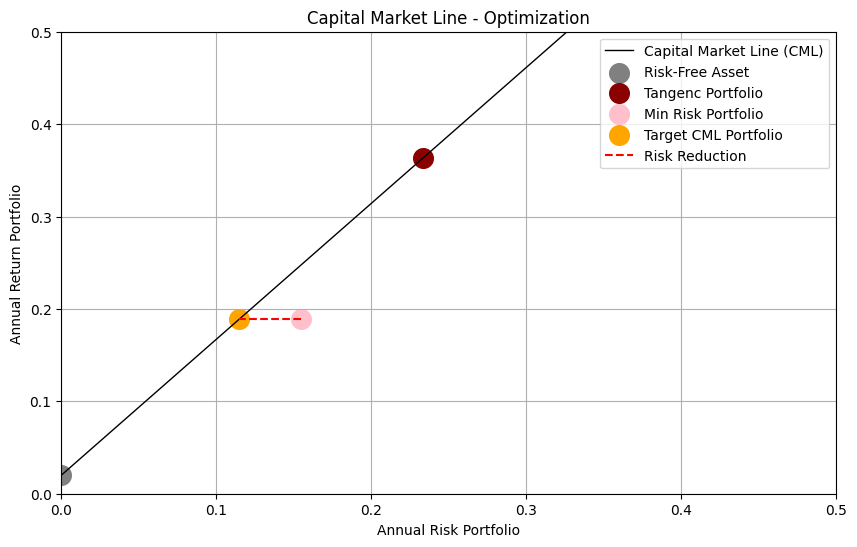

In [120]:
plt.figure(figsize=(10, 6))

plt.plot(risk_range, cml, color='black', linestyle='-', linewidth=1, label='Capital Market Line (CML)')

plt.scatter(0,rf,color='gray',s=200,label='Risk-Free Asset')

plt.scatter(
    max_sharpe_portfolio['Risk'], max_sharpe_portfolio['Return'],
    marker='o', s=200, label='Tangenc Portfolio',color='darkred'
)

plt.scatter(
    min_risk_portfolio['Risk'], min_risk_portfolio['Return'],
    marker='o', s=200, label='Min Risk Portfolio', color='pink'
)

plt.scatter(
    target_risk_cml,
    return_cml,
    marker='o',
    s=200,
    label='Target CML Portfolio',
    color='orange'
)

plt.plot(
    [min_risk_portfolio['Risk'], target_risk_cml],
    [min_risk_portfolio['Return'], return_cml],
    color='red',
    linewidth=1.5,
    linestyle='--',
    label='Risk Reduction'
)




plt.title('Capital Market Line - Optimization')
plt.xlabel('Annual Risk Portfolio')
plt.ylabel('Annual Return Portfolio')
plt.legend()
plt.ylim(0,0.5)
plt.xlim(0,0.5)
plt.grid(True)



# **ВЫВОД И ЗАКЛЮЧЕНИЕ**

Из проэкта мы узнали:

*   Еффективные портфели лежат на эффективной границе, т.е  мы находим максимальную доходность для любого заданного риска
*   Самый оптимальный портфель  является портфель с максимальным коэффициентом Шарпа,
имея показатели:

     Return = 0.3635,

     Risk = 0.235,

     Sharpe = 1.4700.

*   Этот портфель является тангенциальным, он находится и на эффективной границе ,а также на линии капитала CML делая его самым еффективным из всех 1 000 000 сгенерируемых портфелей.

*   Выбор портфеля зависит от цели инвестора. Инвестор может  воспользоваться всеми портфелями лежащих на еффективной границе. К примеру взять защитный портфель минимального риска, который имеет показатели:

     Return = 0.1891,

     Risk = 0.1546,

     Sharpe = 1.0943.

*   Этот портфель хоть и находится на еффективной границе, но он не лежит на линии капитала CML.
*   В этом случае мы должны сместить его на данную линию. Это делается путем перераспределением капитала между тангенциальным портфелем и портфелем безрискового актива. Вложив 49,22% капитала в тангенциальный портфель и 50,77% в безрисковый актив. Мы получаем портфель с показателями:

     Return = 0.1891,

     Risk = 0.1149,

     Sharpe = 1.4700.

*   Этот портфель лежит на линии капитала т.к имеет Шарп = 1,47 как и у тангенциального портфеля. При этом имея дохлдность = 0,1891 как и у портфеля с минимальным риском, его риск снизился с 0,1546 до 0,1149.
*   Комбинация безрискового актива и портфеля с максимальным коэффициентом Шарпа доминирует над любым портфелем на эффективной границе. **Эффективный инвестор всегда находится на прямой CML.**













